<a href="https://colab.research.google.com/github/Sahil-K-Y/AI-ML-Blueprint/blob/main/Phase-6%20-%20Deep%20Learning%20%26%20PyTorch/087_momentum_nag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 087 — Momentum & Nesterov Accelerations

**Phase 6: Deep Learning & PyTorch**

## 📌 Topics
- Exponentially weighted moving averages
- Momentum update math
- Nesterov Accelerated Gradient (NAG) look-ahead


In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt


In [3]:
np.random.seed(42)
raw_gradients = np.random.randint(1, 11, size=30)  # noisy gradients

In [4]:
def ewma(data, beta):
    v = 0
    smoothed = []
    for value in data:
        v = beta * v + (1 - beta) * value
        smoothed.append(v)
    return smoothed

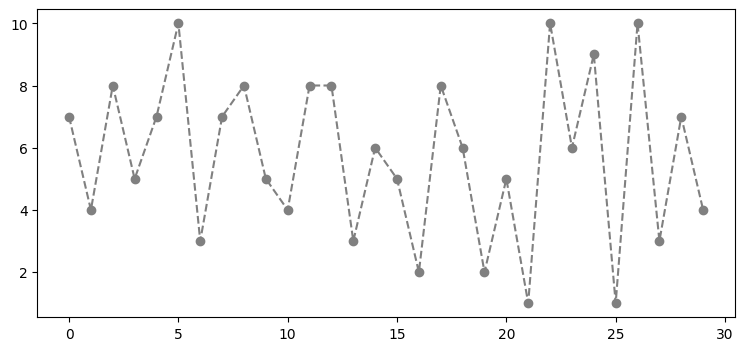

In [5]:
betas = [0.5, 0.9, 0.99]
plt.figure(figsize=(9, 4))
plt.plot(raw_gradients, label="Raw Gradients (noisy)", color="gray", linestyle="--", marker="o")

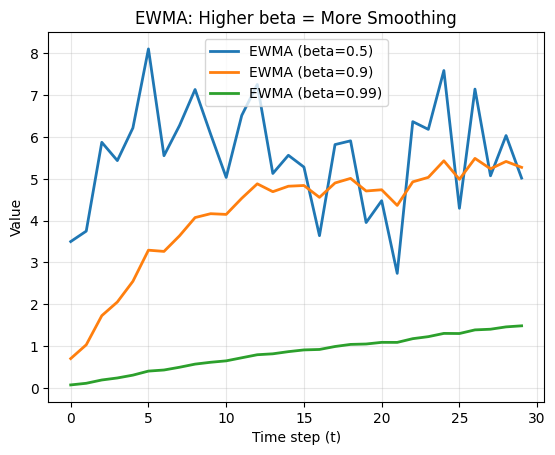

In [6]:
for beta in betas:
    smoothed = ewma(raw_gradients, beta)
    plt.plot(smoothed, label=f"EWMA (beta={beta})", lw=2)

plt.title("EWMA: Higher beta = More Smoothing")
plt.xlabel("Time step (t)")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
def momentum_optimizer(theta_init, gradients, alpha=0.1, beta=0.9):
    theta = theta_init
    v = 0.0
    history = {"theta": [theta], "v": [v]}

    for grad in gradients:
        v = beta * v + (1 - beta) * grad     # 1. Velocity update (EWMA of gradients)
        theta = theta - alpha * v            # 2. Parameter update
        history["theta"].append(theta)
        history["v"].append(v)

    return theta, history

# Test run with fixed gradients
gradients_example = [10, 2, 8, 1, 9]
final_theta, hist = momentum_optimizer(theta_init=5.0, gradients=gradients_example)

print("=== Momentum Update Trace ===")
for t, (v, th) in enumerate(zip(hist["v"][1:], hist["theta"][1:]), start=1):
    print(f"t={t}: v={v:.2f}, theta={th:.2f}")

print(f"\nFinal theta: {final_theta:.2f}")

=== Momentum Update Trace ===
t=1: v=1.00, theta=4.90
t=2: v=1.10, theta=4.79
t=3: v=1.79, theta=4.61
t=4: v=1.71, theta=4.44
t=5: v=2.44, theta=4.20

Final theta: 4.20


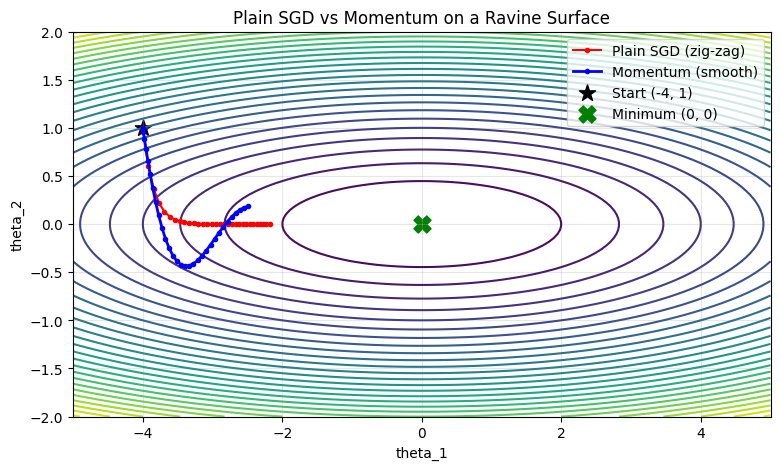

In [8]:
def loss_fn(x, y):
    return 0.1 * x**2 + 2 * y**2      # y steep, x flat

def grad_fn(x, y):
    return np.array([0.2 * x, 4.0 * y])

# 1. Plain SGD (No momentum)
def plain_sgd(start, lr=0.1, steps=30):
    pos = np.array(start, dtype=float)
    path = [pos.copy()]
    for _ in range(steps):
        grad = grad_fn(*pos)
        pos = pos - lr * grad
        path.append(pos.copy())
    return np.array(path)

# 2. Momentum GD
def momentum_gd(start, lr=0.1, beta=0.9, steps=30):
    pos = np.array(start, dtype=float)
    v = np.zeros_like(pos)
    path = [pos.copy()]
    for _ in range(steps):
        grad = grad_fn(*pos)
        v = beta * v + (1 - beta) * grad
        pos = pos - lr * v
        path.append(pos.copy())
    return np.array(path)


start_point = [-4.0, 1.0]
path_sgd = plain_sgd(start_point)
path_momentum = momentum_gd(start_point)

# Contour meshgrid
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = loss_fn(X, Y)

# Visualization
plt.figure(figsize=(9, 5))
plt.contour(X, Y, Z, levels=30, cmap="viridis")
plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'r.-', label="Plain SGD (zig-zag)")
plt.plot(path_momentum[:, 0], path_momentum[:, 1], 'b.-', lw=2, label="Momentum (smooth)")
plt.scatter(*start_point, color="black", marker="*", s=150, label="Start (-4, 1)")
plt.scatter(0, 0, color="green", marker="X", s=150, label="Minimum (0, 0)")
plt.title("Plain SGD vs Momentum on a Ravine Surface")
plt.xlabel("theta_1")
plt.ylabel("theta_2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

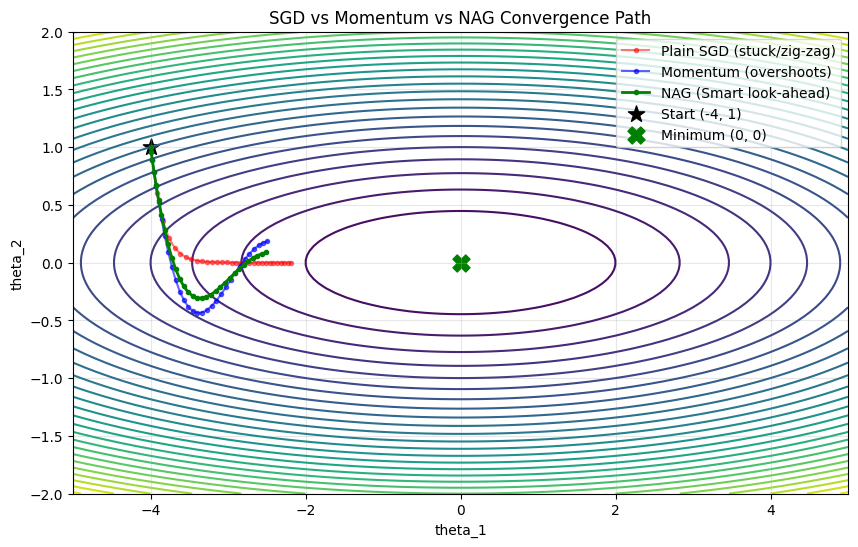

In [9]:
def nag_gd(start, lr=0.1, beta=0.9, steps=30):
    pos = np.array(start, dtype=float)
    v = np.zeros_like(pos)
    path = [pos.copy()]

    for _ in range(steps):

        lookahead = pos - lr * beta * v


        grad = grad_fn(*lookahead)


        v = beta * v + (1 - beta) * grad
        pos = pos - lr * v
        path.append(pos.copy())

    return np.array(path)

# Run NAG on the same starting point
path_nag = nag_gd(start_point)

# 3-Way Comparison Plot (SGD vs Momentum vs NAG)
plt.figure(figsize=(10, 6))
plt.contour(X, Y, Z, levels=30, cmap="viridis")

plt.plot(path_sgd[:, 0], path_sgd[:, 1], 'r.-', label="Plain SGD (stuck/zig-zag)", alpha=0.5)
plt.plot(path_momentum[:, 0], path_momentum[:, 1], 'b.-', label="Momentum (overshoots)", alpha=0.6)
plt.plot(path_nag[:, 0], path_nag[:, 1], 'g.-', lw=2, label="NAG (Smart look-ahead)")

plt.scatter(*start_point, color="black", marker="*", s=150, label="Start (-4, 1)")
plt.scatter(0, 0, color="green", marker="X", s=150, label="Minimum (0, 0)")

plt.title("SGD vs Momentum vs NAG Convergence Path")
plt.xlabel("theta_1")
plt.ylabel("theta_2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()